House Price Prediction
Internship Project – Week 1

Name: Riya Dobhal  
Objective: Predict house prices using machine learning and compare Linear Regression with Random Forest.

Task 1: 
1.1 Loading the csv file using pandas and 
1.2 displaying the first 10 rows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


1.3 Displaying number of rows and columns.

In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 545
Number of columns: 13


1.4 Displaying target column and feature columns.

In [3]:
print(df.columns.tolist())
print("Target column:", "price")
print("Feature columns:", [col for col in df.columns if col != "price"])

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
Target column: price
Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


1.5 Checking if there are any null/missing values.

In [4]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


summary statistics for all the numeric columns in the dataframe.

In [5]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


Task 2: 
2.1 Dropping the duplicate rows.

In [6]:
print("Before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

Before removing duplicates: (545, 13)
After removing duplicates: (545, 13)


-there are no missing values.

2.2 Handling missing values.
there are no missing values.Therefore, no imputation was required.But if there were, they can be handled this way.

In [7]:
print(df.isnull().sum())

df.fillna(df.mean(numeric_only=True), inplace=True)

print("Missing values after cleaning:", df.isnull().sum().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
Missing values after cleaning: 0


2.3 Fetching the columns with categorical values(yes/no) then performing one hot encoding on them. 

In [8]:
print(df.dtypes)
df = pd.get_dummies(df, drop_first=True)

print("After encoding, columns are:")
print(df.columns.tolist())

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object
After encoding, columns are:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


2.4 clean data with only meaningful columns for predicting the price.

In [9]:
print(df.shape)
df.head()

(545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


Task 3: 
3.1 Separating features and target.

In [10]:
X = df.drop("price", axis=1)
y = df["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (545, 13)
Target shape: (545,)


Split into training and test sets 

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 436
Testing rows: 109


3.2 Training Linear Regression

In [12]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
print("Linear Regression predictions done!")

Linear Regression predictions done!


3.3 Training Random Forest

In [13]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("Random Forest predictions done!")

Random Forest predictions done!


3.4 Calculating MAE, RMSE, and R² Score then comparing the performance Random forest and Linear Regression model

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"\n {name}")
    print(f"  MAE   (avg error in ₹): {mae:,.0f}")
    print(f"  RMSE  (penalizes big errors): {rmse:,.0f}")
    print(f"  R² Score (1.0 = perfect): {r2:.4f}")

evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)


 Linear Regression
  MAE   (avg error in ₹): 970,043
  RMSE  (penalizes big errors): 1,324,507
  R² Score (1.0 = perfect): 0.6529

 Random Forest
  MAE   (avg error in ₹): 1,021,546
  RMSE  (penalizes big errors): 1,400,566
  R² Score (1.0 = perfect): 0.6119


Task 4: Visualization
4.1 Distribution of House Prices using Histogram

Chart 1


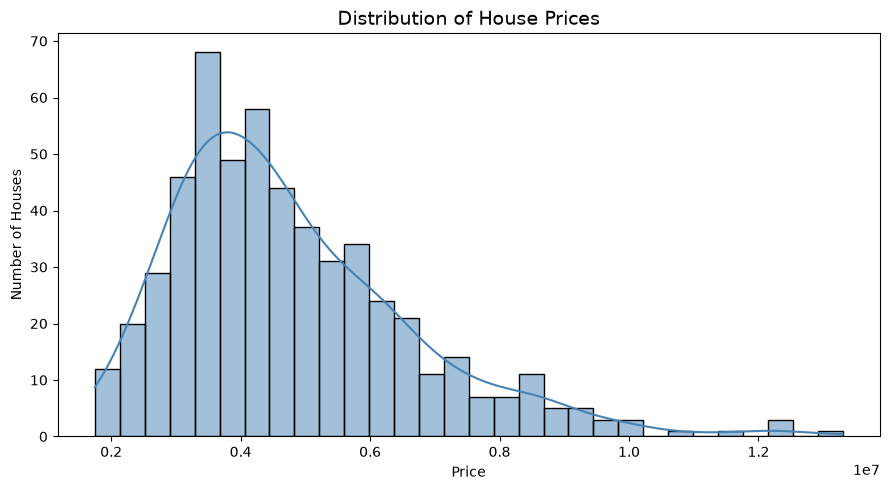

In [15]:
print("Chart 1")
plt.figure(figsize=(9, 5))
sns.histplot(df["price"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of House Prices", fontsize=14)
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.savefig("charts/chart1_price_distribution.png")
plt.show()

Observation: Most houses are concentrated in the lower to mid-price range, with relatively few high-priced properties, indicating a right-skewed distribution.

4.2 Correlation Heatmap

Chart 2


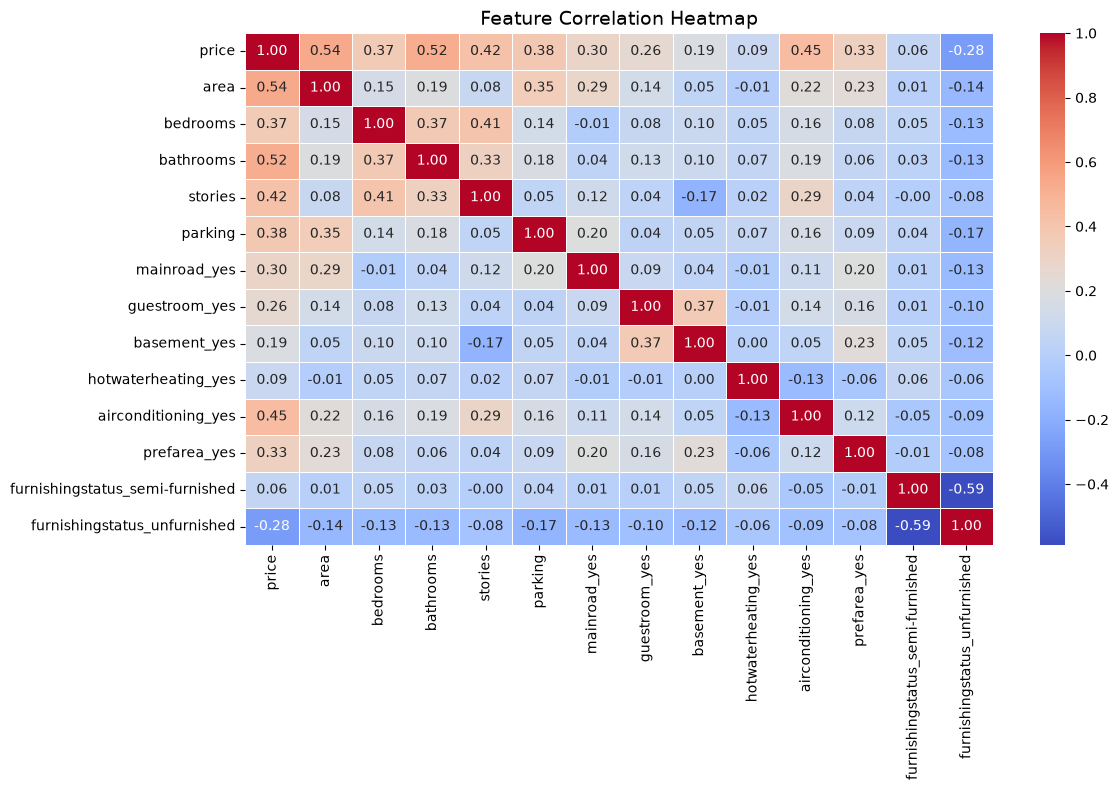

In [16]:
print("Chart 2")
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.savefig("charts/chart2_correlation_heatmap.png")
plt.show()

Observation: Area and bathrooms exhibit some of the strongest positive correlations with price.

4.3 Actual vs Predicted Price (Random Forest)

Chart 3


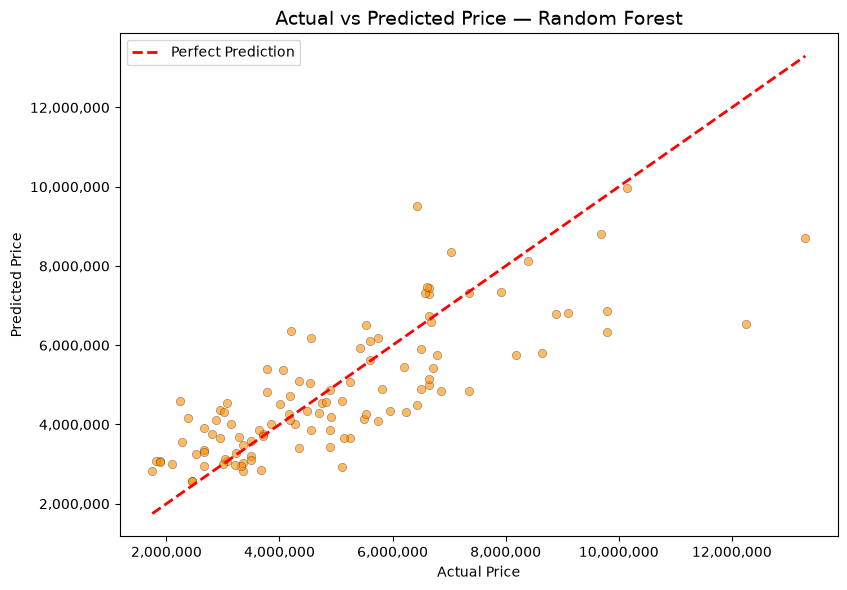

In [17]:
print("Chart 3")
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color="darkorange", edgecolors="black", linewidth=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price — Random Forest", fontsize=14)
plt.legend()
plt.tight_layout()

import matplotlib.ticker as ticker
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.savefig("charts/chart3_actual_vs_predicted.png")
plt.show()

4.4 the Feature Importance bar chart from Random Forest

Chart 4


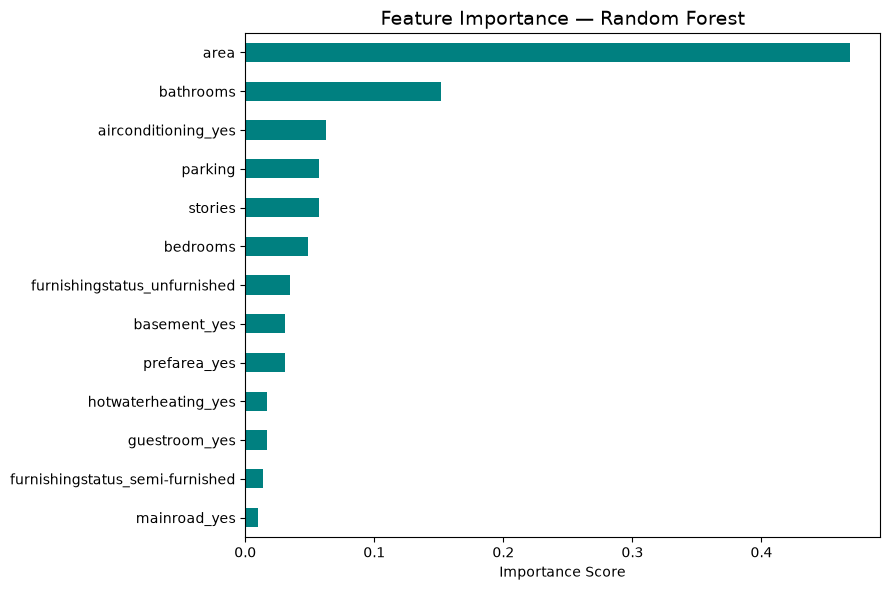

In [18]:
print("Chart 4")
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
importances.plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Feature Importance — Random Forest", fontsize=14)
plt.tight_layout()
plt.savefig("charts/chart4_feature_importance.png")
plt.show()

Observation: Area is by far the most influential feature in the Random Forest model, followed by bathrooms and air conditioning.

Task 5: Insights & Summary

1. Which features influence house price the most?

-Looking at the correlation heatmap, area had the strongest relationship with price — which makes intuitive sense, bigger homes cost more. Number of bathrooms and stories also stood out as fairly strong predictors. Surprisingly, bedrooms alone weren't as strongly correlated with price as I
expected; it seems buyers value usable space (area, bathrooms) more than just bedroom count.

2. How accurate was your model (in plain terms)?

-Interestingly, Linear Regression slightly outperformed Random Forest here, with an R² of 0.65 compared to Random Forest's 0.61 — meaning Linear Regression explained about 65% of the variation in house prices. The average prediction error (MAE) was around ₹9,70,043 for Linear Regression and ₹10,21,546 for Random Forest. This was a bit unexpected since Random Forest usually performs better on complex data, but it suggests the relationship between features and price in this dataset is fairly linear, so the simpler model generalized better.

3. What surprised you in the data?

-I didn't expect Linear Regression to beat Random Forest — I assumed the more complex model would automatically do better. It made me realize that a more powerful model isn't always the right choice; with a smaller dataset like this, Random Forest may have slightly overfit the training data, while Linear Regression captured the overall trend more reliably.

4. One recommendation for a real estate business:

-Since area and bathrooms are the biggest price drivers, and the Linear Regression model performed reasonably well, a real estate business could use a simple linear pricing model based on these key features to quickly generate baseline estimates for new listings. This keeps the pricing process fast and interpretable, while still leaving room for adjustments based on factors the model doesn't capture, like neighborhood or condition.